# EfficientRainbow ± FHR — λ/r tuning grid (50k-step preliminary)

CX3 **tune** campaign (`experiments/hpc/cx3`, manifest family `effrainbowtune`):
**5 games × 8 arms × 3 seeds at 50k env steps** (half the Atari-100k budget), a
grid around the suite anchor **exp3 (λ=2, r=8)**. Games were picked from the
1-seed 100k suite's per-game ΔHNS: **Boxing** (+1.47) and **BankHeist** (+0.62)
as wins, **KungFuMaster** and **BattleZone** as washes, **DemonAttack** (−0.33)
as the worst loss.

| arm | λ (`fhr_weight`) | r (`fhr_order`) | role |
|---|---|---|---|
| baseline | — | — | TD only |
| exp10 | 1 | 8 | λ sweep |
| **exp3** | **2** | **8** | **suite anchor** |
| exp11 | 4 | 8 | λ sweep |
| exp14 | 10 | 8 | λ sweep |
| exp15 | 100 | 8 | λ sweep |
| exp12 | 2 | 4 | r sweep |
| exp13 | 2 | 16 | r sweep |

Protocol: `config_effrainbow_tune.yaml` per game — 50k env steps, greedy eval
checkpoints every ~5k env steps (8 episodes → `eval.csv`), final evaluation
32 full-game episodes at ε=0.001 (`eval_summary.json`, HNS against the
EfficientZero Table 1 random/human references). This notebook reads **completed
runs only**, directly from `dqn_<game>/cached/runs/*_effrainbowtune_*` — it
never launches anything and is robust to partially-finished games.


## 0 · Discover completed runs


In [1]:
import json, pathlib, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", message="Mean of empty slice")

SRC = pathlib.Path.cwd().parents[1] / "src"        # repo library code
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from analysis.atari100k import REFERENCE, hns

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})

TUNE_STEPS = 50_000
SEEDS = (0, 1, 2)
# arm -> (λ, r); display order: baseline, λ sweep at r=8, r sweep at λ=2.
ARM_HP = {"baseline": None,
          "exp10": (1, 8), "exp3": (2, 8), "exp11": (4, 8),
          "exp14": (10, 8), "exp15": (100, 8),
          "exp12": (2, 4), "exp13": (2, 16)}
ARM_ORDER = list(ARM_HP)
def arm_label(a):
    hp = ARM_HP[a]
    return "baseline" if hp is None else f"\u03bb={hp[0]:g}, r={hp[1]}"

# A run counts as completed iff its final eval was written.
RUNS = {}   # game_dir -> arm -> {seed: {"summary", "dir"}}
for summ in sorted(pathlib.Path.cwd().glob(
        "dqn_*/cached/runs/*_effrainbowtune_*/eval_summary.json")):
    s = json.loads(summ.read_text())
    game_dir = summ.parents[3].name
    arm = s["name_tag"] or s["arm"]          # exp arms carry arm="fhr"
    RUNS.setdefault(game_dir, {}).setdefault(arm, {})[s["seed"]] =         {"summary": s, "dir": summ.parent}

GAMES = sorted(RUNS)
GAME_KEY = {g: next(iter(RUNS[g][a].values()))["summary"]["game"]
            for g in GAMES for a in (next(iter(RUNS[g])),)}

# Completion matrix: seeds done per game x arm.
n_total = 0
w = max(len(g) for g in GAMES) + 2
print("seeds completed (of 3)")
print(" " * w + "  ".join(f"{a:>8}" for a in ARM_ORDER))
for g in GAMES:
    row = []
    for a in ARM_ORDER:
        n = len(RUNS[g].get(a, {}))
        n_total += n
        row.append(f"{n:>8}")
    print(f"{g:<{w}}" + "  ".join(row))
COMPLETE_GAMES = [g for g in GAMES
                  if all(len(RUNS[g].get(a, {})) == len(SEEDS) for a in ARM_ORDER)]
print(f"\n{n_total}/{len(GAMES) * len(ARM_ORDER) * len(SEEDS)} runs completed; "
      f"grid-complete games: {', '.join(COMPLETE_GAMES)}")


seeds completed (of 3)
                    baseline     exp10      exp3     exp11     exp14     exp15     exp12     exp13
dqn_bank_heist             3         3         3         3         3         3         3         3
dqn_battle_zone            3         3         3         3         3         3         3         3
dqn_boxing                 3         3         3         3         3         3         3         3
dqn_demon_attack           3         3         3         3         3         3         3         3
dqn_kung_fu_master         3         3         3         3         3         3         3         3

120/120 runs completed; grid-complete games: dqn_bank_heist, dqn_battle_zone, dqn_boxing, dqn_demon_attack, dqn_kung_fu_master


## 1 · Final-evaluation table

Mean over 3 seeds of the final 32-episode ε=0.001 evaluation; ΔHNS is against
the same game's baseline arm. Seed spread is the *population* std of the
per-seed eval means.


In [2]:
FINAL = {}   # game -> arm -> {"raw": per-seed eval means, "hns": per-seed HNS}
for g in GAMES:
    FINAL[g] = {}
    for a in ARM_ORDER:
        if a not in RUNS[g]:
            continue
        seeds = sorted(RUNS[g][a])
        FINAL[g][a] = {
            "raw": np.array([RUNS[g][a][s]["summary"]["mean"] for s in seeds]),
            "hns": np.array([RUNS[g][a][s]["summary"]["hns_mean"] for s in seeds]),
            "seeds": seeds,
        }

for g in GAMES:
    base = FINAL[g].get("baseline")
    ref = REFERENCE[GAME_KEY[g]]
    print(f"\n{GAME_KEY[g]}  (random {ref['random']:g}, human {ref['human']:g})")
    print(f"  {'arm':<12}{'raw mean':>10}{'±std':>8}{'HNS':>9}{'±std':>8}"
          f"{'ΔHNS':>9}  seeds")
    for a in ARM_ORDER:
        if a not in FINAL[g]:
            continue
        f = FINAL[g][a]
        d = f["hns"].mean() - base["hns"].mean() if base is not None else np.nan
        flag = "" if len(f["seeds"]) == len(SEEDS) else "  (partial!)"
        print(f"  {arm_label(a):<12}{f['raw'].mean():>10.1f}{f['raw'].std():>8.1f}"
              f"{f['hns'].mean():>9.3f}{f['hns'].std():>8.3f}"
              f"{d:>+9.3f}  {f['seeds']}{flag}")



BankHeist  (random 14.2, human 753.1)
  arm           raw mean    ±std      HNS    ±std     ΔHNS  seeds
  baseline          38.9    19.3    0.033   0.026   +0.000  [0, 1, 2]
  λ=1, r=8          39.6    26.5    0.034   0.036   +0.001  [0, 1, 2]
  λ=2, r=8          17.4    13.4    0.004   0.018   -0.029  [0, 1, 2]
  λ=4, r=8          16.7     5.8    0.003   0.008   -0.030  [0, 1, 2]
  λ=10, r=8         39.1    20.8    0.034   0.028   +0.000  [0, 1, 2]
  λ=100, r=8        17.2     1.9    0.004   0.003   -0.029  [0, 1, 2]
  λ=2, r=4          14.5     4.1    0.000   0.006   -0.033  [0, 1, 2]
  λ=2, r=16         14.4     1.5    0.000   0.002   -0.033  [0, 1, 2]

BattleZone  (random 2360, human 37187.5)
  arm           raw mean    ±std      HNS    ±std     ΔHNS  seeds
  baseline        5770.8  1352.4    0.098   0.039   +0.000  [0, 1, 2]
  λ=1, r=8        4343.8  2347.3    0.057   0.067   -0.041  [0, 1, 2]
  λ=2, r=8        6541.7  2555.8    0.120   0.073   +0.022  [0, 1, 2]
  λ=4, r=8       

## 2 · λ and r sweeps — final HNS per game

Left block: λ ∈ {1, 2, 4, 10, 100} at r=8 (baseline plotted at the left edge).
Right block: r ∈ {4, 8, 16} at λ=2 (baseline as the dashed line). Dots are
individual seeds, the line joins seed means.


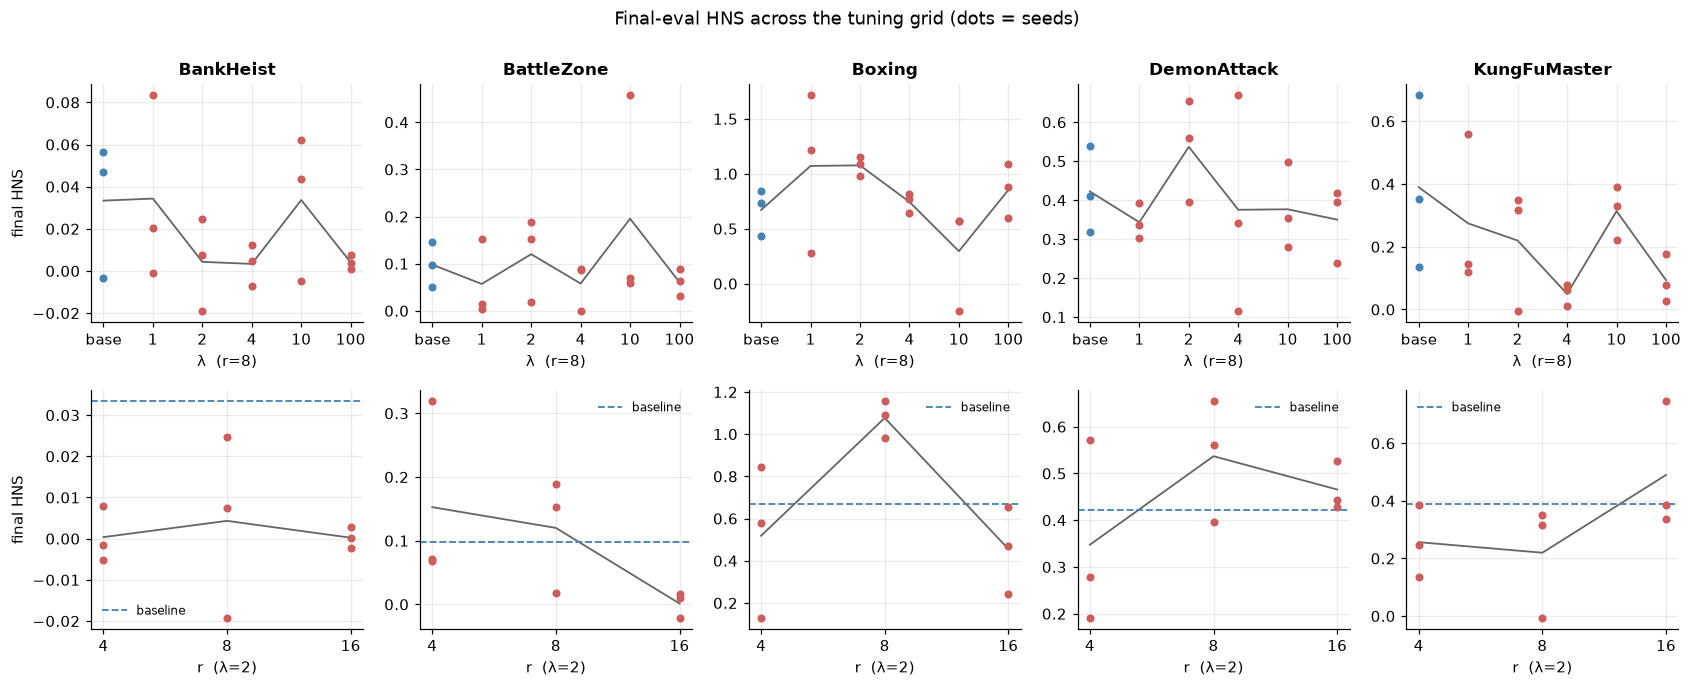

In [3]:
LAM_ARMS = ["exp10", "exp3", "exp11", "exp14", "exp15"]   # λ = 1,2,4,10,100 @ r8
R_ARMS = ["exp12", "exp3", "exp13"]                       # r = 4,8,16 @ λ2

fig, axes = plt.subplots(2, len(GAMES), figsize=(3.1 * len(GAMES), 6.2),
                         squeeze=False)
for j, g in enumerate(GAMES):
    base = FINAL[g].get("baseline")

    ax = axes[0][j]
    xs = np.arange(1 + len(LAM_ARMS))
    labels, means = ["base"], []
    if base is not None:
        ax.scatter([0] * len(base["hns"]), base["hns"], s=18, color="steelblue",
                   zorder=3)
        means.append(base["hns"].mean())
    else:
        means.append(np.nan)
    for k, a in enumerate(LAM_ARMS, start=1):
        labels.append(f"{ARM_HP[a][0]:g}")
        if a in FINAL[g]:
            ax.scatter([k] * len(FINAL[g][a]["hns"]), FINAL[g][a]["hns"], s=18,
                       color="indianred", zorder=3)
            means.append(FINAL[g][a]["hns"].mean())
        else:
            means.append(np.nan)
    ax.plot(xs, means, color="0.4", lw=1.2, zorder=2)
    ax.set_xticks(xs, labels)
    ax.set_title(GAME_KEY[g])
    if j == 0:
        ax.set_ylabel("final HNS")
    ax.set_xlabel("\u03bb  (r=8)")

    ax = axes[1][j]
    xs = np.arange(len(R_ARMS))
    labels, means = [], []
    for k, a in enumerate(R_ARMS):
        labels.append(str(ARM_HP[a][1]))
        if a in FINAL[g]:
            ax.scatter([k] * len(FINAL[g][a]["hns"]), FINAL[g][a]["hns"], s=18,
                       color="indianred", zorder=3)
            means.append(FINAL[g][a]["hns"].mean())
        else:
            means.append(np.nan)
    ax.plot(xs, means, color="0.4", lw=1.2, zorder=2)
    if base is not None:
        ax.axhline(base["hns"].mean(), color="steelblue", ls="--", lw=1.2,
                   label="baseline")
        ax.legend(loc="best", fontsize=8)
    ax.set_xticks(xs, labels)
    if j == 0:
        ax.set_ylabel("final HNS")
    ax.set_xlabel("r  (\u03bb=2)")
fig.suptitle("Final-eval HNS across the tuning grid (dots = seeds)", y=1.0)
fig.tight_layout()
plt.show()


## 3 · Eval-checkpoint learning curves

Greedy 8-episode evaluations every ~5k env steps (`eval.csv`), converted to
HNS, interpolated onto a common 5k grid and averaged over seeds.


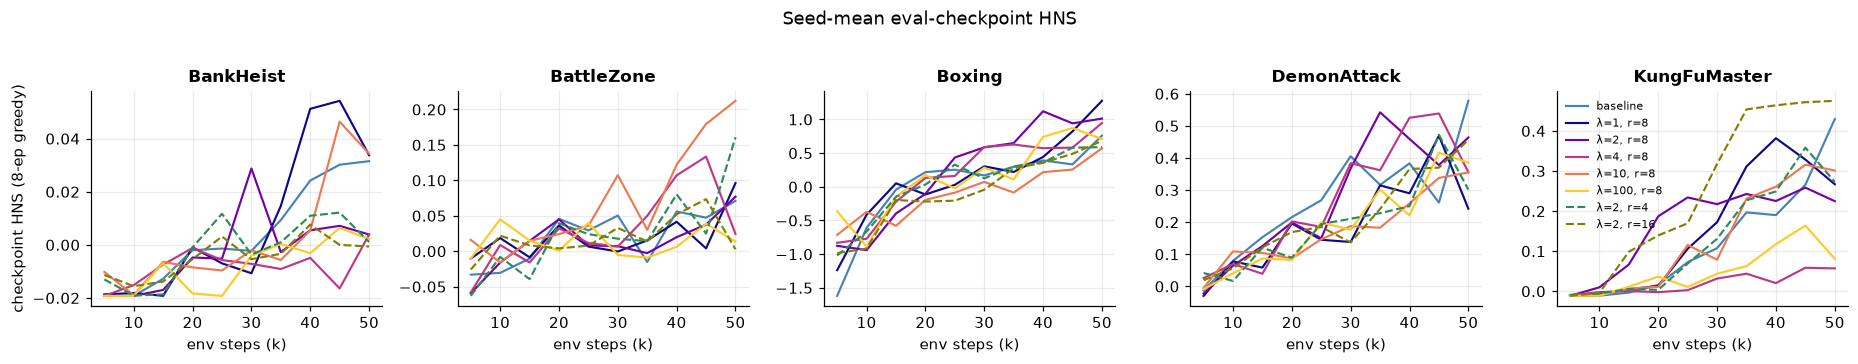

In [4]:
GRID = np.arange(5_000, TUNE_STEPS + 1, 5_000)
cmap = plt.get_cmap("plasma")
lam_color = {a: cmap(i / (len(LAM_ARMS) - 0.5)) for i, a in enumerate(LAM_ARMS)}
ARM_COLOR = {"baseline": "steelblue", **lam_color,
             "exp12": "seagreen", "exp13": "olive"}
ARM_STYLE = {a: ("--" if a in ("exp12", "exp13") else "-") for a in ARM_ORDER}

def eval_curve(run_dir, game_key):
    d = np.genfromtxt(run_dir / "eval.csv", delimiter=",", names=True)
    d = np.atleast_1d(d)
    return d["env_steps"], np.array([hns(m, game_key) for m in d["mean_reward"]])

fig, axes = plt.subplots(1, len(GAMES), figsize=(3.4 * len(GAMES), 3.2),
                         squeeze=False)
for j, g in enumerate(GAMES):
    ax = axes[0][j]
    for a in ARM_ORDER:
        if a not in RUNS[g]:
            continue
        curves = []
        for s, r in sorted(RUNS[g][a].items()):
            if not (r["dir"] / "eval.csv").exists():
                continue
            steps, h = eval_curve(r["dir"], GAME_KEY[g])
            curves.append(np.interp(GRID, steps, h))
        if not curves:
            continue
        m = np.mean(curves, axis=0)
        ax.plot(GRID / 1e3, m, color=ARM_COLOR[a], ls=ARM_STYLE[a], lw=1.4,
                label=arm_label(a))
    ax.set_title(GAME_KEY[g])
    ax.set_xlabel("env steps (k)")
    if j == 0:
        ax.set_ylabel("checkpoint HNS (8-ep greedy)")
axes[0][-1].legend(fontsize=7, loc="best")
fig.suptitle("Seed-mean eval-checkpoint HNS", y=1.02)
fig.tight_layout()
plt.show()


## 4 · Aggregate over grid-complete games

Only games with the full 8×3 grid enter (partial games are excluded so every
arm aggregates the same games). ΔHNS is per-game against baseline, then
averaged — this is the number the tuning decision should read.


In [5]:
assert COMPLETE_GAMES, "no grid-complete game yet"
print(f"aggregating {len(COMPLETE_GAMES)} games: "
      f"{', '.join(GAME_KEY[g] for g in COMPLETE_GAMES)}\n")

rows = []
for a in ARM_ORDER:
    h = np.array([FINAL[g][a]["hns"].mean() for g in COMPLETE_GAMES])
    d = np.array([FINAL[g][a]["hns"].mean() - FINAL[g]["baseline"]["hns"].mean()
                  for g in COMPLETE_GAMES])
    rows.append((a, h.mean(), np.median(h), d.mean(),
                 int((d > 0).sum()) if a != "baseline" else 0))

print(f"{'arm':<12}{'mean HNS':>10}{'median':>9}{'mean ΔHNS':>11}{'wins':>6}")
for a, mh, md_, dd, w_ in rows:
    win = f"{w_}/{len(COMPLETE_GAMES)}" if a != "baseline" else "—"
    print(f"{arm_label(a):<12}{mh:>10.3f}{md_:>9.3f}{dd:>+11.3f}{win:>6}")

best = max((r for r in rows if r[0] != "baseline"), key=lambda r: r[3])
print(f"\nbest arm by mean ΔHNS: {best[0]} ({arm_label(best[0])}), "
      f"{best[3]:+.3f} vs baseline")


aggregating 5 games: BankHeist, BattleZone, Boxing, DemonAttack, KungFuMaster

arm           mean HNS   median  mean ΔHNS  wins
baseline         0.323    0.390     +0.000     —
λ=1, r=8         0.356    0.274     +0.033   2/5
λ=2, r=8         0.392    0.220     +0.069   3/5
λ=4, r=8         0.246    0.058     -0.077   1/5
λ=10, r=8        0.243    0.295     -0.080   2/5
λ=100, r=8       0.272    0.094     -0.051   1/5
λ=2, r=4         0.255    0.256     -0.068   1/5
λ=2, r=16        0.283    0.456     -0.040   2/5

best arm by mean ΔHNS: exp3 (λ=2, r=8), +0.069 vs baseline


## 5 · Notes

**Status (2026-09-03).** All **120/120** runs complete — the full 8-arm ×
3-seed grid on all 5 games.

**The suite anchor still wins the grid, but by less than the 4-game
preliminary suggested.** exp3 (λ=2, r=8) remains the best arm by mean ΔHNS
over the 5 games (**+0.069**, 3/5 wins: Boxing +0.406, DemonAttack +0.115,
BattleZone +0.022), and no other arm beats it — the grid found nothing that
argues for changing the suite arm. KungFuMaster, fully in now, is the main
drag: *every* λ hurts it (exp3 −0.170, λ=4 −0.340), consistent with its
"wash" label from the 1-seed 100k suite turning into a mild loss at 50k.

**λ sweep (r=8) — λ=2 is the sweet spot, and the response is non-monotone.**
λ=1 matches λ=2 on Boxing but with enormous seed variance (HNS ±0.60) and
loses BattleZone, DemonAttack and KungFuMaster; λ≥4 degrades the aggregate
(λ=4 −0.077, λ=10 −0.080, λ=100 −0.051). λ=10's BattleZone "+0.098" comes
with ±0.19 seed std — one hot seed, not a signal. Notably even λ=100 doesn't
collapse training: the auxiliary loss saturates rather than destroys the TD
objective.

**r sweep (λ=2) — r=8 best on aggregate, but the order response is the most
game-dependent axis.** r=4 (−0.068) and r=16 (−0.040) both lose overall, yet
r=16 is the *only* arm that wins KungFuMaster (+0.100, and the best median
HNS of the whole grid) while being BattleZone's worst arm (−0.097). If any
follow-up tuning is worth GPU hours, it's per-game order selection, not λ.

**Caveats.** (i) 50k steps is half the real budget — BankHeist, a +0.62 win
in the 1-seed 100k suite, shows nothing at 50k (every arm ≤ baseline, all HNS
≈ 0.03 or less), so per-game deltas here don't necessarily transfer to 100k.
(ii) 3 seeds against seed stds of 0.1–0.2 HNS: treat per-game |ΔHNS| ≲ 0.1 as
noise; the aggregate ordering is the trustworthy readout.

**Decision:** keep **exp3 (λ=2, r=8)** as the suite/ref arm and spend the
remaining GPU budget on the 27-game 100k campaign.
